# 3Di Alignment Benchmark

## Description

We compare the performance of ESM3Di against ProstT5 on the MetaVR sequence set.

We have 3 different 3Di representations of the MetaVR sequence set:
* **AF3**: 3Di generated by Foldseek based on the predicted AlphaFold3 structures of the MetaVR sequence set.
* **ProstT5**: 3Di generated by ProstT5 based on the sequences of the MetaVR sequence set.
* **ESM3Di**: 3Di generated by ESM3Di based on the sequences of the MetaVR sequence set.

We compile each representation into a Foldseek database and run Foldseek's `structurealign` module on a 1-vs-1 basis (aligning identical entries).

The results are represented as the **bitscore** of the alignment and **3Di sequence identity**.

The **bitscore** is a measure of the overall similarity between two aligned 3Di sequences. It rewards long, well-matching alignments while penalizing mismatches and gaps, with higher bitscores indicating more similar 3Di representations.

The **3Di sequence identity** is calculated as:

$$
\text{Identity} = \frac{\text{\# of residues with identical 3Di}}{\text{\# of residues}}
$$

In [ ]:
# Setup cell: Install foldseek if not already present in the environment
import shutil

if not shutil.which("foldseek"):
    print("Foldseek not found. Installing via Conda...")
    %conda install -y -c conda-forge -c bioconda foldseek
else:
    print("Foldseek is already installed.")

Foldseek is already installed.


In [3]:
import os
import subprocess
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

# --- Configuration ---
DATAPATH = Path("./data")
DATAPATH.mkdir(parents=True, exist_ok=True)

FS_DIR = DATAPATH / "foldseek"
META_DIR = DATAPATH / "metavr"
FS_DIR.mkdir(exist_ok=True)
META_DIR.mkdir(exist_ok=True)

# --- Utility Functions ---
def run_cmd(cmd: str, silent: bool = False):
    """Executes shell commands safely and raises informative errors on failure."""
    res = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if res.returncode != 0:
        raise RuntimeError(f"Command failed:\n{cmd}\n\nError output:\n{res.stderr}")
    if not silent and res.stdout.strip():
        print(res.stdout.strip())
    return res.stdout

def write_fasta(sequences: dict[str, str], filepath: Path):
    """Writes a dictionary of {id: sequence} to a FASTA file."""
    with open(filepath, "w") as f:
        for seq_id, seq in sequences.items():
            f.write(f">{seq_id}\n{seq}\n")

def parse_fasta(fasta_path: Path) -> dict[str, str]:
    """Reads a FASTA file into a {id: sequence} dictionary."""
    seqs, hdr = {}, None
    with open(fasta_path) as f:
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                hdr = line[1:].split()[0]
                seqs[hdr] = ""
            elif hdr:
                seqs[hdr] += line
    return seqs

In [4]:
import tarfile
from curl_cffi import requests
from tqdm import tqdm

tar_path = META_DIR / "partial_download.tar.gz"
url = "https://www.meta-virome.org/Data/Downloads/IMGVR5_PC_3Dmodels.tar.gz"

max_bytes = 1024 * 1024 * 10#24  # 1 GB cap
downloaded = 0

print("1. Downloading first 1 GB using browser TLS impersonation...")

response = requests.get(url, impersonate="chrome", stream=True)

if response.status_code != 200:
    print(f"Failed with status code: {response.status_code}")
else:
    # Stream download with progress bar
    with open(tar_path, "wb") as f, tqdm(
        total=max_bytes,
        unit="B",
        unit_scale=True,
        unit_divisor=1024,
        desc="Downloading 1GB sample",
    ) as pbar:
        for chunk in response.iter_content(chunk_size=1024 * 1024):
            if not chunk:
                continue

            # Ensure we stop precisely at the 1 GB cap
            bytes_to_write = min(len(chunk), max_bytes - downloaded)
            f.write(chunk[:bytes_to_write])
            downloaded += bytes_to_write
            pbar.update(bytes_to_write)

            if downloaded >= max_bytes:
                break

    print(f"\nDownloaded {downloaded / (1024 * 1024):.2f} MB to {tar_path}")

    print("2. Extracting structures...")

    # Stream mode ("r|gz") reads sequentially and avoids pre-scanning the full file
    try:
        with tarfile.open(tar_path, "r|gz") as tar:
            while True:
                try:
                    member = tar.next()
                    if member is None:
                        break
                    tar.extract(member, path=META_DIR)
                except (EOFError, tarfile.TarError, OSError):
                    # Gracefully stop extraction at the truncated cutoff point
                    print("\nReached the end of the truncated 1 GB stream.")
                    break
    except Exception as e:
        print(f"\nExtraction finished with notice: {e}")

    # Clean up archive file
    if tar_path.exists():
        tar_path.unlink()

    # Count extracted files
    extracted_files = sum(1 for _ in META_DIR.glob("**/*") if _.is_file())
    print(f"3. Done! Total extracted files: {extracted_files}")

1. Downloading first 1 GB using browser TLS impersonation...



Downloaded 10.00 MB to data/metavr/partial_download.tar.gz
2. Extracting structures...

Reached the end of the truncated 1 GB stream.
3. Done! Total extracted files: 338


In [5]:
import os
import random
import shutil


def sample_structures(source_dir, output_dir, n_samples=500, seed=42):
    """Samples `n_samples` PDB/CIF files from source_dir into output_dir."""
    random.seed(seed)  # Fixed seed ensures reproducible sampling
    os.makedirs(output_dir, exist_ok=True)

    # Find all 3D structure files
    valid_exts = (".pdb", ".cif", ".ent", ".pdb.gz", ".cif.gz")
    all_files = [
        f
        for f in os.listdir(source_dir)
        if f.lower().endswith(valid_exts)
        and os.path.isfile(os.path.join(source_dir, f))
    ]

    if not all_files:
        print(f"Error: No structure files found in '{source_dir}'")
        return

    sample_size = min(n_samples, len(all_files))
    sampled_files = random.sample(all_files, sample_size)

    print(f"Found {len(all_files)} structure files in '{source_dir}'.")
    print(f"Copying {sample_size} files to '{output_dir}'...")

    for file_name in sampled_files:
        src = os.path.join(source_dir, file_name)
        dst = os.path.join(output_dir, file_name)
        shutil.copy2(src, dst)

    print(f"Done! Sampled {sample_size} structures successfully.\n")

In [ ]:
n = 10000
SAMPLE_DIR = META_DIR / f"metaVR_structures_{n}"

sample_structures(
    META_DIR / "metaVR_structures_all",
    SAMPLE_DIR,
    n_samples=n,
    seed=42,
)

Found 231 structure files in 'data/metavr/metaVR_structures_all'.
Copying 40 files to 'data/metavr/metaVR_structures_40'...
Done! Sampled 40 structures successfully.



### Ground Truth 3Di from AlphaFold3

In [18]:
af3_db = FS_DIR / "metavr_af3"
fasta = META_DIR / "input_aa.fasta"

# 1. Create the Foldseek database directly from the directory of .cif files
print("Creating Foldseek DB from CIF folder...")
run_cmd(f"foldseek createdb '{SAMPLE_DIR}' '{af3_db}'")

# 2. Export the amino acid sequences from the DB to a standard FASTA file
print("Exporting AA sequences to FASTA...")
run_cmd(f"foldseek convert2fasta '{af3_db}' '{fasta}'")

# 3. Verify the sequence count
aa_seqs = parse_fasta(fasta)
print(f"Successfully extracted {len(aa_seqs)} sequences to {fasta}")

Creating Foldseek DB from CIF folder...
data/foldseek/metavr_af3 exists and will be overwritten
createdb data/metavr/metaVR_structures_40 data/foldseek/metavr_af3 

MMseqs Version:             	10.941cd33
Use GPU                     	0
Path to ProstT5             	
Chain name mode             	0
Createdb extraction mode    	0
Interface distance threshold	8
Write mapping file          	0
Mask b-factor threshold     	0
Coord store mode            	2
Write lookup file           	1
Input format                	0
File Inclusion Regex        	.*
File Exclusion Regex        	^$
Threads                     	8
Verbosity                   	3

Output file: data/foldseek/metavr_af3
[=================================================================] 40 0s 62ms
Time for merging to metavr_af3_ss: 0h 0m 0s 9ms
Time for merging to metavr_af3_h: 0h 0m 0s 8ms
Time for merging to metavr_af3_ca: 0h 0m 0s 10ms
Time for merging to metavr_af3: 0h 0m 0s 8ms
Ignore 0 out of 40.
Too short: 0, incorrect: 0, not p

### Predict 3Di with ProstT5 (General Purpose)

In [ ]:
prost_db = FS_DIR / "metavr_prostt5"

prostt5_weights = DATAPATH / "prostt5_weights"
tmp = DATAPATH / "tmp"
prostt5_weights.mkdir(exist_ok=True)
tmp.mkdir(exist_ok=True)

# if empty directory, download weights
if not any(prostt5_weights.iterdir()):
    run_cmd(
        f"foldseek databases ProstT5 '{prostt5_weights}' '{tmp}'"
    )

# clean up temporary directory
if tmp.exists():
    shutil.rmtree(tmp)

# 4. Create the Foldseek database using the downloaded weights
run_cmd(
    f"foldseek createdb \
    '{fasta}' \
    '{prost_db}' \
    --prostt5-model {prostt5_weights} \
    --gpu 1")

data/foldseek/metavr_prostt5 exists and will be overwritten
data/foldseek/metavr_prostt5 exists and will be overwritten
createdb data/metavr/input_aa.fasta data/foldseek/metavr_prostt5 --prostt5-model data/prostt5_weights 

MMseqs Version:             	10.941cd33
Use GPU                     	0
Path to ProstT5             	data/prostt5_weights
Chain name mode             	0
Createdb extraction mode    	0
Interface distance threshold	8
Write mapping file          	0
Mask b-factor threshold     	0
Coord store mode            	2
Write lookup file           	1
Input format                	0
File Inclusion Regex        	.*
File Exclusion Regex        	^$
Threads                     	8
Verbosity                   	3

Converting sequences
[
Time for merging to metavr_prostt5_h: 0h 0m 0s 12ms
Time for merging to metavr_prostt5: 0h 0m 0s 16ms
Database type: Aminoacid
CPU
[=================================================================] 100 12m 33s 666ms
Time for merging to metavr_prostt5_ss: 0

'data/foldseek/metavr_prostt5 exists and will be overwritten\ndata/foldseek/metavr_prostt5 exists and will be overwritten\ncreatedb data/metavr/input_aa.fasta data/foldseek/metavr_prostt5 --prostt5-model data/prostt5_weights \n\nMMseqs Version:             \t10.941cd33\nUse GPU                     \t0\nPath to ProstT5             \tdata/prostt5_weights\nChain name mode             \t0\nCreatedb extraction mode    \t0\nInterface distance threshold\t8\nWrite mapping file          \t0\nMask b-factor threshold     \t0\nCoord store mode            \t2\nWrite lookup file           \t1\nInput format                \t0\nFile Inclusion Regex        \t.*\nFile Exclusion Regex        \t^$\nThreads                     \t8\nVerbosity                   \t3\n\nConverting sequences\n[\nTime for merging to metavr_prostt5_h: 0h 0m 0s 12ms\nTime for merging to metavr_prostt5: 0h 0m 0s 16ms\nDatabase type: Aminoacid\nCPU\n[=================================================================] 100 12m 33s 666m

### Predict 3Di with ESM3Di (Fine tuned for viral structure)

In [19]:
esm_db = FS_DIR / "metavr_esm3di"

run_cmd(
    f"esm3di foldseek-db \
    --input-fasta '{fasta}' \
    --output-db '{esm_db}'"
    )

16:43:18 [INFO] Loading model from: /Users/finnweikert/Desktop/Dessimoz Lab/ESM3di/esm3di_inference/checkpoints/hf_compatible
16:43:21 [INFO] Using device: cpu (CPU)
16:43:21 [INFO] Reading sequence inputs from: /Users/finnweikert/Desktop/Dessimoz Lab/ESM3di/esm3di_inference/data/metavr/input_aa.fasta
16:45:24 [INFO] Saved predicted 3Di sequences to: /Users/finnweikert/Desktop/Dessimoz Lab/ESM3di/esm3di_inference/data/foldseek/metavr_esm3di_temp_3di.fasta
16:45:24 [INFO] Building Foldseek database at: /Users/finnweikert/Desktop/Dessimoz Lab/ESM3di/esm3di_inference/data/foldseek/metavr_esm3di
16:45:24 [INFO] Foldseek database generated successfully.


'16:43:18 [INFO] Loading model from: /Users/finnweikert/Desktop/Dessimoz Lab/ESM3di/esm3di_inference/checkpoints/hf_compatible\n16:43:21 [INFO] Using device: cpu (CPU)\n16:43:21 [INFO] Reading sequence inputs from: /Users/finnweikert/Desktop/Dessimoz Lab/ESM3di/esm3di_inference/data/metavr/input_aa.fasta\n16:45:24 [INFO] Saved predicted 3Di sequences to: /Users/finnweikert/Desktop/Dessimoz Lab/ESM3di/esm3di_inference/data/foldseek/metavr_esm3di_temp_3di.fasta\n16:45:24 [INFO] Building Foldseek database at: /Users/finnweikert/Desktop/Dessimoz Lab/ESM3di/esm3di_inference/data/foldseek/metavr_esm3di\n16:45:24 [INFO] Foldseek database generated successfully.\n'

### 3Di FASTA Extraction, Foldseek Alignment & Metric Evaluation
Extract 3Di FASTA files from the Foldseek databases, align predictions against AF3 ground truth, and calculate both **bitscores** and **3Di sequence identity**.

In [9]:
# --- 1. Extract 3Di Sequences to FASTA Files ---
def convert_db_3di_to_fasta(db_prefix: Path, out_fasta: Path):
    """Extracts 3Di sequences from Foldseek _ss database into a standard FASTA file."""
    # Link header DB to secondary structure DB and dump FASTA
    run_cmd(f"foldseek base:lndb '{db_prefix}_h' '{db_prefix}_ss_h'", silent=True)
    run_cmd(f"foldseek convert2fasta '{db_prefix}_ss' '{out_fasta}'", silent=True)

print("Extracting 3Di FASTA sequences from Foldseek DBs...")
convert_db_3di_to_fasta(af3_db, META_DIR / "metavr_af3_3di.fa")
convert_db_3di_to_fasta(prost_db, META_DIR / "metavr_prostt5_3di.fa")
convert_db_3di_to_fasta(esm_db, META_DIR / "metavr_esm3di_3di.fa")
print("3Di FASTA files generated successfully!")


# --- 2. Prefilter & Foldseek Structure Alignment ---
def get_foldseek_header_map(db_prefix: Path) -> dict[str, int]:
    """Parses Foldseek's binary _h database using byte offsets from _h.index."""
    idx_path = db_prefix.with_name(f"{db_prefix.name}_h.index")
    hdr_path = db_prefix.with_name(f"{db_prefix.name}_h")

    header_to_id = {}
    with open(idx_path, "r", encoding="utf-8") as f_idx, open(hdr_path, "rb") as f_hdr:
        for line in f_idx:
            parts = line.strip().split("\t")
            if len(parts) < 3:
                continue
            key = int(parts[0])      # True internal Foldseek entry ID
            offset = int(parts[1])   # Byte offset in _h
            length = int(parts[2])   # Byte length in _h

            f_hdr.seek(offset)
            raw_bytes = f_hdr.read(length)
            # Clean null bytes and extract primary header identifier
            hdr_str = raw_bytes.decode("latin1").replace("\x00", "").strip().split()[0]
            header_to_id[hdr_str] = key

    return header_to_id


def create_1v1_prefilter(query_prefix: Path, target_prefix: Path, out_tsv: Path, out_db: Path):
    """Generates a 1-vs-1 mapping prefilter DB for Foldseek structurealign."""
    q_map = get_foldseek_header_map(query_prefix)
    t_map = get_foldseek_header_map(target_prefix)

    pairs = []
    for hdr, q_id in q_map.items():
        if hdr in t_map:
            pairs.append((q_id, t_map[hdr]))

    if not pairs:
        raise RuntimeError(f"No matching headers found between {query_prefix.name} and {target_prefix.name}")

    pd.DataFrame(pairs).to_csv(out_tsv, sep="\t", header=False, index=False)
    run_cmd(f"foldseek base:tsv2db '{out_tsv}' '{out_db}' --output-dbtype 7", silent=True)


def run_foldseek_alignment(query_db: Path, target_db: Path, pref_db: Path, out_prefix: Path) -> pd.DataFrame:
    """Runs structurealign and returns a formatted DataFrame containing bitscores."""
    aln_db = out_prefix.with_suffix(".aln")
    tsv_out = out_prefix.with_suffix(".tsv")
    fields = "query,target,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue,bits"

    run_cmd(f"foldseek structurealign -e INF '{query_db}' '{target_db}' '{pref_db}' '{aln_db}'", silent=True)
    run_cmd(f"foldseek convertalis '{query_db}' '{target_db}' '{aln_db}' '{tsv_out}' --format-output '{fields}'", silent=True)
    return pd.read_csv(tsv_out, sep="\t", names=fields.split(","))

print("\nAligning ProstT5 vs AF3...")
create_1v1_prefilter(prost_db, af3_db, META_DIR / "prost_pref.tsv", FS_DIR / "prost_pref")
df_prost = run_foldseek_alignment(prost_db, af3_db, FS_DIR / "prost_pref", FS_DIR / "prost_aln")

print("Aligning ESM3Di vs AF3...")
create_1v1_prefilter(esm_db, af3_db, META_DIR / "esm_pref.tsv", FS_DIR / "esm_pref")
df_esm = run_foldseek_alignment(esm_db, af3_db, FS_DIR / "esm_pref", FS_DIR / "esm_aln")


# --- 3. Compute 3Di Sequence Identities ---
af3_seqs = parse_fasta(META_DIR / "metavr_af3_3di.fa")
prost_seqs = parse_fasta(META_DIR / "metavr_prostt5_3di.fa")
esm_seqs = parse_fasta(META_DIR / "metavr_esm3di_3di.fa")

identities = []
for seq_id, af3_seq in af3_seqs.items():
    if seq_id in prost_seqs and seq_id in esm_seqs:
        p_seq, e_seq = prost_seqs[seq_id], esm_seqs[seq_id]
        if len(af3_seq) == len(p_seq) == len(e_seq):
            identities.append({
                "query": seq_id,
                "prostt5_identity": sum(a == b for a, b in zip(af3_seq, p_seq)) / len(af3_seq) * 100,
                "esm3di_identity": sum(a == b for a, b in zip(af3_seq, e_seq)) / len(af3_seq) * 100
            })

# --- 4. Merge Bitscores and Identities into Unified Benchmark DataFrame ---
df_benchmark = (
    df_prost[["query", "bits"]]
    .rename(columns={"bits": "prostt5_bitscore"})
    .merge(df_esm[["query", "bits"]].rename(columns={"bits": "esm3di_bitscore"}), on="query")
    .merge(pd.DataFrame(identities), on="query")
)

print(f"\nBenchmark dataset ready. Total sequences matched: {len(df_benchmark)}")
df_benchmark.head()

Extracting 3Di FASTA sequences from Foldseek DBs...
3Di FASTA files generated successfully!

Aligning ProstT5 vs AF3...
Aligning ESM3Di vs AF3...

Benchmark dataset ready. Total sequences matched: 10


,query,prostt5_bitscore,esm3di_bitscore,prostt5_identity,esm3di_identity
0,imgvr_pc_000043808,1136,1096,50.000000,45.161290
1,imgvr_pc_000205787,1275,1054,71.717172,57.575758
2,imgvr_pc_000292411,553,470,65.714286,56.190476
3,imgvr_pc_000423339,1159,1044,70.886076,61.603376
4,imgvr_pc_000652344,442,482,51.000000,67.000000


### Benchmark Results: Bitscores & 3Di Sequence Identity
Compare **ProstT5** and **ESM3Di** performance directly against AlphaFold3 ground truth representations.

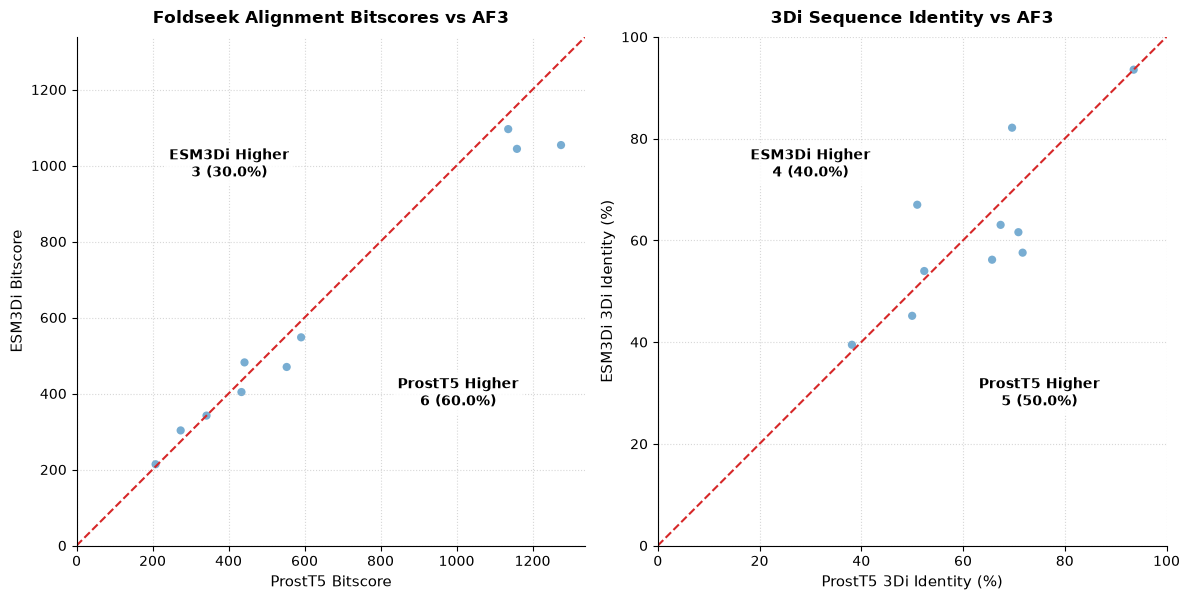


             BENCHMARK SUMMARY             
                 Metric    ProstT5     ESM3Di
          Mean Bitscore 641.400000 595.700000
        Median Bitscore 497.500000 476.000000
  Mean 3Di Identity (%)  63.043893  61.970756
Median 3Di Identity (%)  66.552795  59.589567


In [10]:
def plot_benchmark_comparison(df, x_col, y_col, x_label, y_label, title, kind="scatter", gridsize=30, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    x, y = df[x_col].values, df[y_col].values
    if len(df) == 0:
        return ax

    n_total = len(df)
    n_above, n_below = np.sum(y > x), np.sum(y < x)
    pct_above, pct_below = (n_above / n_total) * 100, (n_below / n_total) * 100

    # Dynamic limits: Fixed cap at 100 for percentages, otherwise dynamic max
    max_val = max(x.max(), y.max())
    if "identity" in x_col.lower() and max_val <= 100:
        lim = 100.0
    else:
        lim = max_val * 1.05 if max_val > 0 else 1.0

    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_aspect("equal", adjustable="box")

    # Render points using identical styling rules
    if kind == "hexbin" and len(df) > 10:
        hb = ax.hexbin(x, y, gridsize=gridsize, extent=(0, lim, 0, lim), cmap="viridis", mincnt=1)
        cb = plt.colorbar(hb, ax=ax, label="Count", fraction=0.046, pad=0.04)
        cb.ax.tick_params(labelsize=9)
    else:
        ax.scatter(x, y, alpha=0.6, edgecolors="none", color="#1f77b4", s=35)

    # Reference Identity line y = x
    ax.plot([0, lim], [0, lim], color="#d62728", linestyle="--", linewidth=1.5, label="y = x")

    # Annotations
    bbox_props = dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85, edgecolor="none")
    ax.text(0.30, 0.75, f"ESM3Di Higher\n{n_above} ({pct_above:.1f}%)", transform=ax.transAxes, ha="center", va="center", fontsize=10, fontweight="bold", bbox=bbox_props)
    ax.text(0.75, 0.30, f"ProstT5 Higher\n{n_below} ({pct_below:.1f}%)", transform=ax.transAxes, ha="center", va="center", fontsize=10, fontweight="bold", bbox=bbox_props)

    # Styling
    ax.set_xlabel(x_label, fontsize=11)
    ax.set_ylabel(y_label, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.grid(True, linestyle=":", alpha=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    return ax


# Set a uniform style for both subplots ("scatter" or "hexbin")
PLOT_STYLE = "scatter"  # Switch to "hexbin" if scaling up to thousands of sequences

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot 1: Bitscores
plot_benchmark_comparison(
    df=df_benchmark,
    x_col="prostt5_bitscore",
    y_col="esm3di_bitscore",
    x_label="ProstT5 Bitscore",
    y_label="ESM3Di Bitscore",
    title="Foldseek Alignment Bitscores vs AF3",
    kind=PLOT_STYLE,
    ax=axes[0]
)

# Plot 2: 3Di Identity
plot_benchmark_comparison(
    df=df_benchmark,
    x_col="prostt5_identity",
    y_col="esm3di_identity",
    x_label="ProstT5 3Di Identity (%)",
    y_label="ESM3Di 3Di Identity (%)",
    title="3Di Sequence Identity vs AF3",
    kind=PLOT_STYLE,
    ax=axes[1]
)

plt.tight_layout()
plt.show()

# --- Print Summary Metrics ---
print("\n" + "=" * 45)
print("             BENCHMARK SUMMARY             ")
print("=" * 45)
summary_df = pd.DataFrame({
    "Metric": ["Mean Bitscore", "Median Bitscore", "Mean 3Di Identity (%)", "Median 3Di Identity (%)"],
    "ProstT5": [
        df_benchmark["prostt5_bitscore"].mean(),
        df_benchmark["prostt5_bitscore"].median(),
        df_benchmark["prostt5_identity"].mean(),
        df_benchmark["prostt5_identity"].median(),
    ],
    "ESM3Di": [
        df_benchmark["esm3di_bitscore"].mean(),
        df_benchmark["esm3di_bitscore"].median(),
        df_benchmark["esm3di_identity"].mean(),
        df_benchmark["esm3di_identity"].median(),
    ]
})
print(summary_df.to_string(index=False))